## Theorem 3

In [9]:
import numpy as np
import gurobipy as gp
from yahoofinancials import YahooFinancials
from gurobipy import GRB
import matplotlib.pyplot as plt


#Upper Bound Solver
mu = 100.0
sigma = 20.0
variance = sigma ** 2
strike = 110.0

xmin = 0
xmax = 250
n_grid = 500

x = np.linspace(xmin, xmax, n_grid)
dx = x[1] - x[0]
model = gp.Model("option_bound")
model.setParam("OutputFlag", 0)


# probability mass at each grid point
p = model.addVars(n_grid, lb=0.0, name="p")




model.addConstr(gp.quicksum(p[i] for i in range(n_grid)) == 1)

model.addConstr(
    gp.quicksum(x[i] * p[i] for i in range(n_grid)) == mu
)

model.addConstr(
    gp.quicksum((x[i] ** 2) * p[i] for i in range(n_grid))
    == variance + mu ** 2
)



payoff = [(max(0, xi - strike)) for xi in x]

model.setObjective(
    gp.quicksum(payoff[i] * p[i] for i in range(n_grid)),
    GRB.MAXIMIZE
)



model.optimize()




upper_bound = model.objVal

print("Optimal Upper Bound:", upper_bound)


probabilities = np.array([p[i].X for i in range(n_grid)])

nonzero = probabilities > 1e-6

print("Support points:")
for xi, pi in zip(x[nonzero], probabilities[nonzero]):
    print(f"x={xi:.2f}, p={pi:.6f}")

Optimal Upper Bound: 6.180120965026181
Support points:
x=87.68, p=0.724765
x=132.26, p=0.171164
x=132.77, p=0.104071


In [10]:
#Analytical Upper Bound

mu = 100
sigma = 20
k = 110

bound = 0.5 * (
    (mu - k)
    + np.sqrt(sigma**2 + (mu - k)**2)
)

print(bound)

6.180339887498949


## Thoerem 4

Lower Bound: 2.1
Upper Bound: 5.55


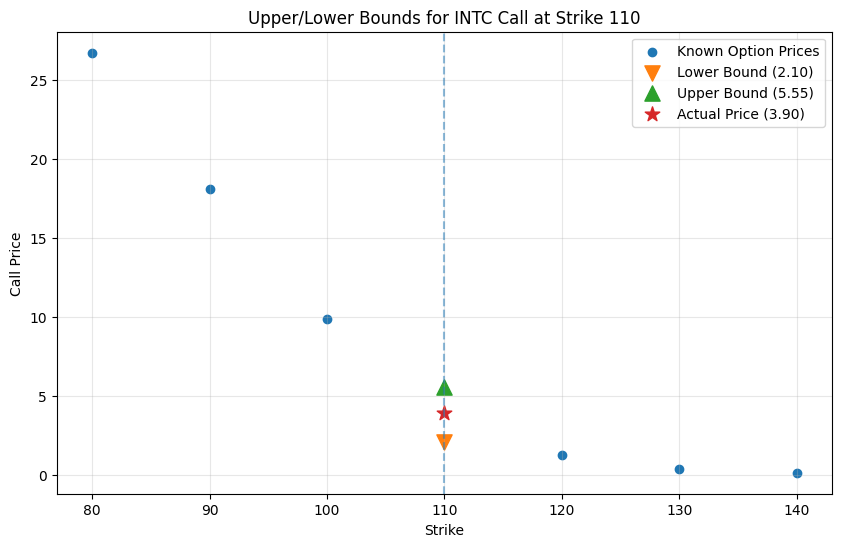

In [16]:
#Solving Upper and Lower Bounds
#INTC Data
known_strikes = np.array([80, 90, 100, 120, 130, 140])

known_prices = np.array([26.72, 18.1, 9.85, 1.25, 0.4, 0.14])

query_strike = 110

actual_price = 3.9

x = np.linspace(0, 300, 600)
n = len(x)



model = gp.Model("call_bounds")
model.setParam("OutputFlag", 0)

p = model.addVars(n, lb=0.0)



model.addConstr(gp.quicksum(p[i] for i in range(n)) == 1)


for K, q in zip(known_strikes, known_prices):

    payoff = np.maximum(0, x - K)

    model.addConstr(
        gp.quicksum(payoff[i] * p[i] for i in range(n))
        == q
    )



query_payoff = np.maximum(0, x - query_strike)



model.setObjective(
    gp.quicksum(query_payoff[i] * p[i] for i in range(n)),
    GRB.MAXIMIZE
)

model.optimize()

upper = model.objVal



model.setObjective(
    gp.quicksum(query_payoff[i] * p[i] for i in range(n)),
    GRB.MINIMIZE
)

model.optimize()

lower = model.objVal


print("Lower Bound:", lower)
print("Upper Bound:", upper)

plt.figure(figsize=(10, 6))

# known market prices
plt.scatter(
    known_strikes,
    known_prices,

    label="Known Option Prices"
)

# lower bound
plt.scatter(
    query_strike,
    lower,
    s=120,
    marker='v',
    label=f"Lower Bound ({lower:.2f})"
)

# upper bound
plt.scatter(
    query_strike,
    upper,
    s=120,
    marker='^',
    label=f"Upper Bound ({upper:.2f})"
)

# actual price
plt.scatter(
    query_strike,
    actual_price,
    s=120,
    marker='*',
    label=f"Actual Price ({actual_price:.2f})"
)

# vertical guide line
plt.axvline(query_strike, linestyle='--', alpha=0.5)

plt.xlabel("Strike")
plt.ylabel("Call Price")
plt.title("Upper/Lower Bounds for INTC Call at Strike 110")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [17]:
#Volatility Bounds

strikes = np.array([80, 90, 100, 120, 130, 140])

prices = np.array([26.72, 18.1, 9.85, 1.25, 0.4, 0.14])



x = np.linspace(0, 250, 500)
n = len(x)



model = gp.Model("variance_bounds")
model.setParam("OutputFlag", 0)

p = model.addVars(n, lb=0)


model.addConstr(gp.quicksum(p[i] for i in range(n)) == 1)

for K, q in zip(strikes, prices):

    payoff = np.maximum(0, x - K)

    model.addConstr(
        gp.quicksum(payoff[i] * p[i] for i in range(n))
        == q
    )



mean_expr = gp.quicksum(x[i] * p[i] for i in range(n))

second_moment_expr = gp.quicksum((x[i]**2) * p[i] for i in range(n))

variance_expr = second_moment_expr - mean_expr * mean_expr


model.setObjective(variance_expr, GRB.MAXIMIZE)

model.optimize()

print("Upper Variance Bound:", model.objVal)

Upper Variance Bound: 1622.105533125863
